In [ ]:
# Should be executed first in a fresh venv
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

# Imports

In [1]:
from scipy.stats import ttest_ind, ttest_rel
import anndata as ad
import scanpy as sc
import numpy as np
import os

from hygeia.utils.hplots import violin_plot

In [2]:
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Liberation Sans'
matplotlib.rcParams['mathtext.default'] = 'regular'
matplotlib.rcParams['axes.unicode_minus'] = False

# Colors

In [3]:
label_color_dict = {
    f'Control': '#708090',
    f'Stimulated':'#FFC0CB',
    f'Predicted stimulated':'#d62728',
}

In [4]:
def get_violin(ood_cov, save_path):

    # Read original data
    adata_observed = sc.read_h5ad(
    '../../Datasets/preprocessed_datasets/kang.h5ad'
    )
    
    # Read prediction for OOD (Unseen stimulated cell_type)
    adata_pred = sc.read_h5ad(
        f'../../Benchmarks/SCDISENTANGLE/Kang/predictions/kang/{ood_cov}_1.h5ad'
    )

    # Get median
    mask_train = adata_observed.obs[f'split_stimulated_{ood_cov}'] == 'train'
    train_median = np.median(
        adata_observed[mask_train].layers['counts'].sum(axis=1)
    )
    print('train_median', train_median)

    # Normalize original data
    sc.pp.normalize_total(adata_observed, target_sum=train_median)
    sc.pp.log1p(adata_observed)

    # Normalize prediction
    sc.pp.normalize_total(adata_pred, target_sum=train_median)
    sc.pp.log1p(adata_pred)
    
    # pred = (original cells are ctrl, cell_type=OOD, prediction is condition=stimulated)
    mask_pred = (
        (adata_pred.obs['condition_org'] == 'control') & 
        (adata_pred.obs['cell_type'] == ood_cov) & 
        (adata_pred.obs['condition_pred'] == 'stimulated')
    )

    # gt is (condition=stimulated, cell_type=ood)
    mask_observed = (
        (adata_observed.obs['condition'] == 'stimulated') & 
        (adata_observed.obs['cell_type'] == ood_cov)
    )
    
    # ctrl is condition=ctrl, cell_type=ood
    mask_ctrl = (
        (adata_observed.obs['condition'] == 'control') & 
        (adata_observed.obs['cell_type'] == ood_cov) & 
        (adata_observed.obs[f'split_stimulated_{ood_cov}'] == 'train')
    )

    # subset observed & pred
    adata_ctrl = adata_observed[mask_ctrl].copy()
    adata_observed_ood = adata_observed[mask_observed].copy()
    adata_pred_ood = adata_pred[mask_pred].copy()

    # TOP ood DEG
    top_deg = adata_observed.uns['rank_genes_groups_condition']['stimulated'][ood_cov][0]

    # Create label
    adata_ctrl.obs['custom_label'] = f'Control'
    adata_observed_ood.obs['custom_label'] = f'Stimulated'
    adata_pred_ood.obs['custom_label'] = f'Predicted stimulated'

    # Concat
    adata_cat = ad.concat([
        adata_ctrl,
        adata_observed_ood, 
        adata_pred_ood
    ]
    )

    # Violin plot
    violin_plot(
        adata=adata_cat,
        variable_of_interest=top_deg,
        label_column_name='custom_label',
        title=f'{ood_cov} Cells',
        x_name='',
        y_name=f'{top_deg} Log expression',
        violin_color='Black',
        figsize=(7, 4.5),
        label_color_dict=label_color_dict,
        save_path=save_path,
        inner='quart',
        despine=True
    )

    # Align pred with control to run paired t-test
    ctrl = adata_ctrl
    gt = adata_observed_ood
    pred = adata_pred_ood

    pred_ids = pred.obs['sc_cell_ids'].to_numpy()
    ctrl_ids = ctrl.obs['sc_cell_ids'].to_numpy()

    ctrl_map = {cid: i for i, cid in enumerate(ctrl_ids)}
    ctrl_idx = [ctrl_map[cid] for cid in pred_ids]
    ctrl = ctrl[ctrl_idx].copy()

    assert ctrl.obs['sc_cell_ids'].tolist() == pred.obs['sc_cell_ids'].tolist()
    
    # Ttest between pred and gt
    ttest_pred_gt = ttest_ind(
        pred[:, top_deg].X.squeeze(),
        gt[:, top_deg].X.squeeze(),
        )

    # Ttest between pred and ctrl
    ttest_pred_ctrl = ttest_rel(
        pred[:, top_deg].X.squeeze(),
        ctrl[:, top_deg].X.squeeze()
    )

    print(f'ttest pred-gt {ood_cov}', ttest_pred_gt)
    print(f'ttest pred-control {ood_cov}', ttest_pred_ctrl)

In [5]:
save_dir= f'{FIG_ROOT}/Kang/violinplots/'
os.makedirs(save_dir, exist_ok=True)

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
adata.X seems to be already log-transformed.


train_median 1704.0


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


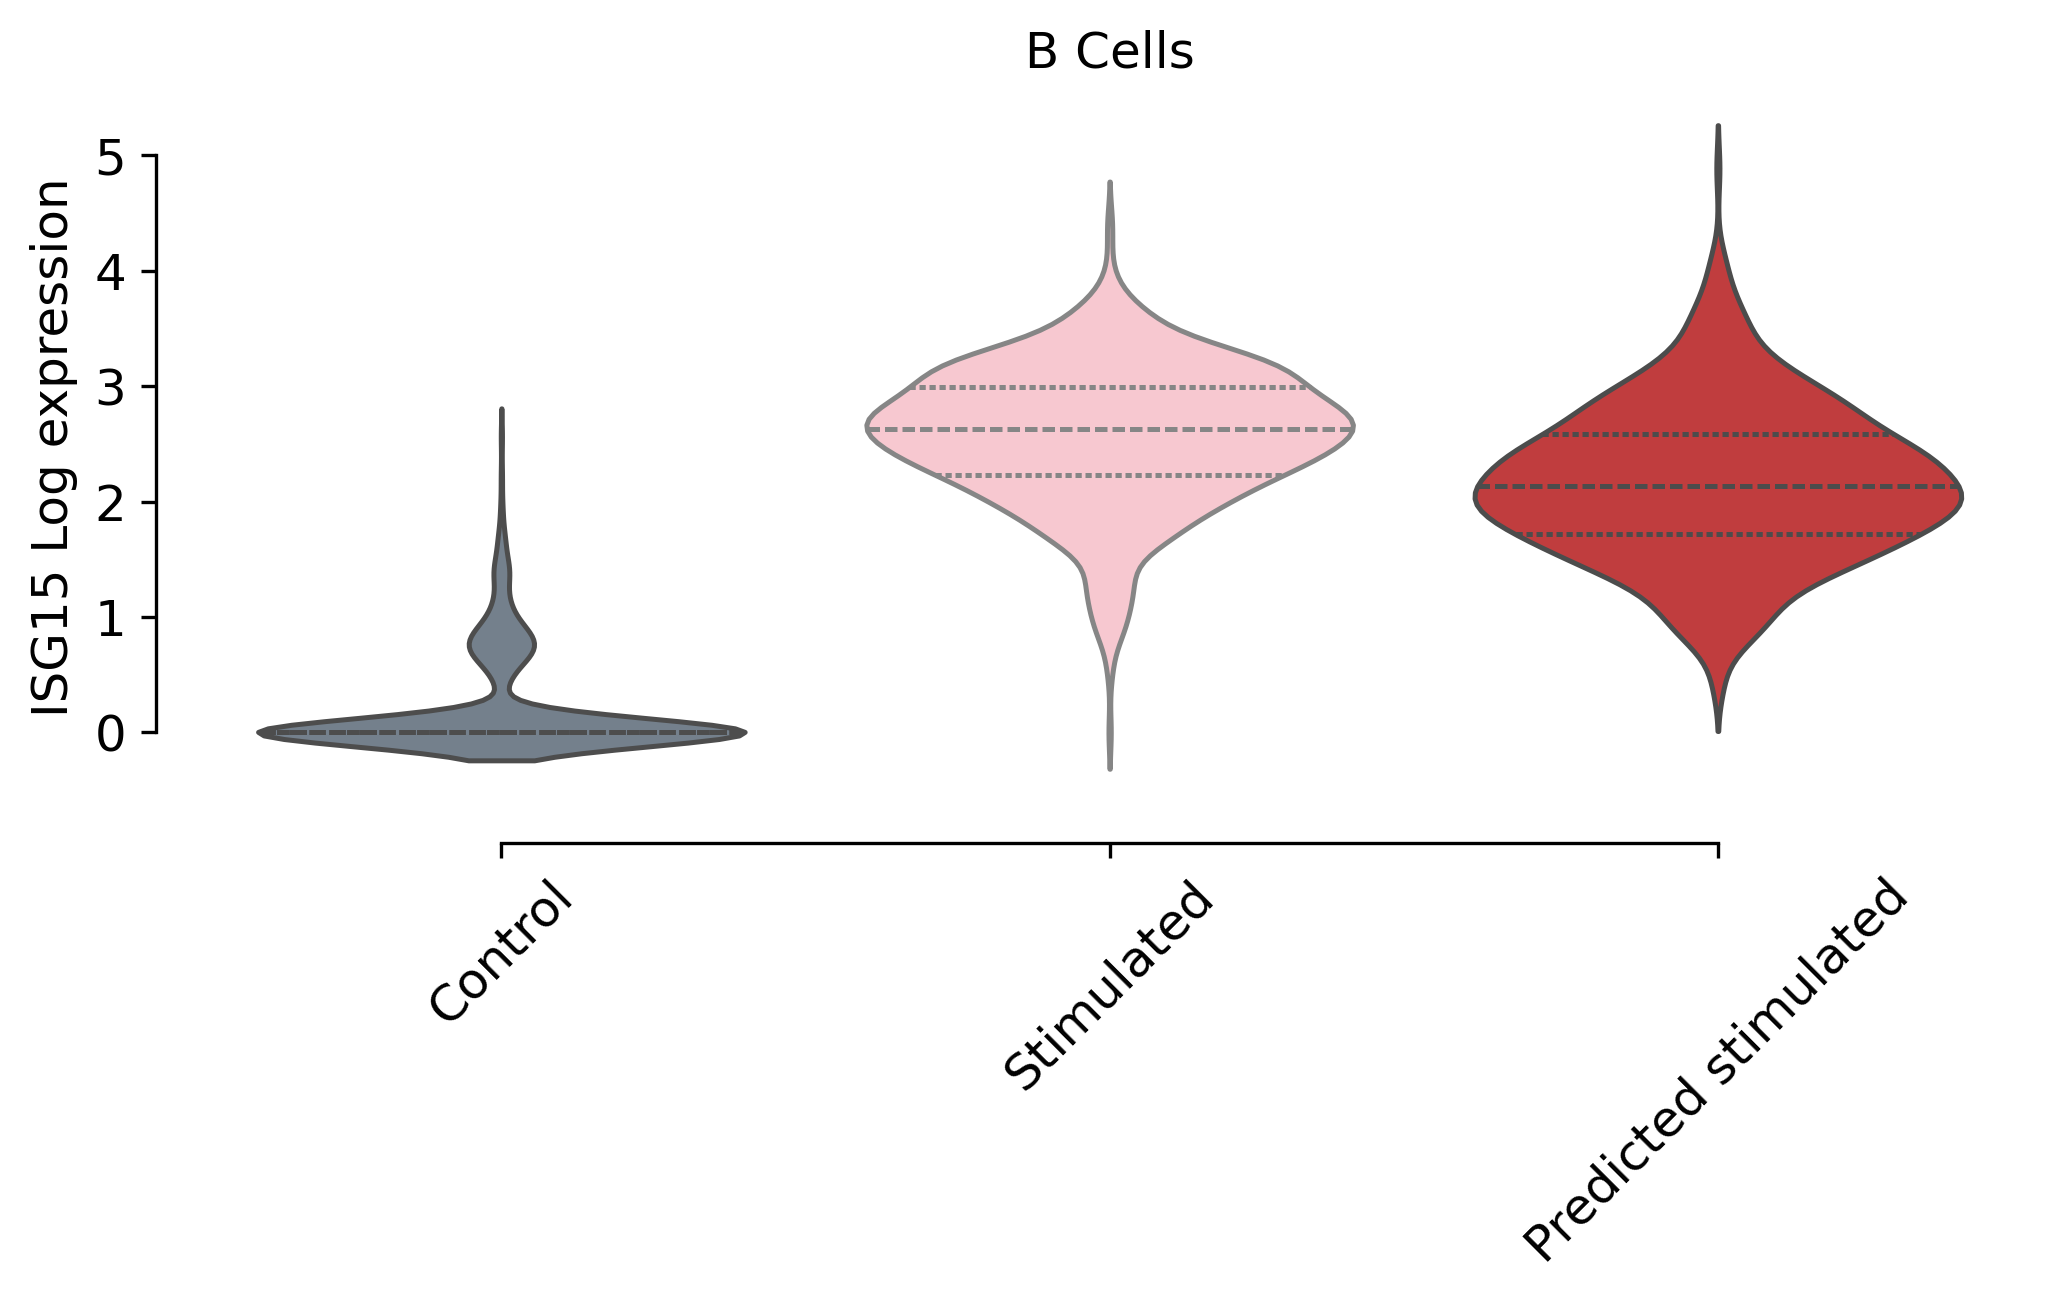

ttest pred-gt B TtestResult(statistic=-11.857266307483641, pvalue=6.95925160921693e-31, df=1314.0)
ttest pred-control B TtestResult(statistic=71.65511026633372, pvalue=2.6883653394597386e-278, df=541)


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
adata.X seems to be already log-transformed.


train_median 1872.5


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


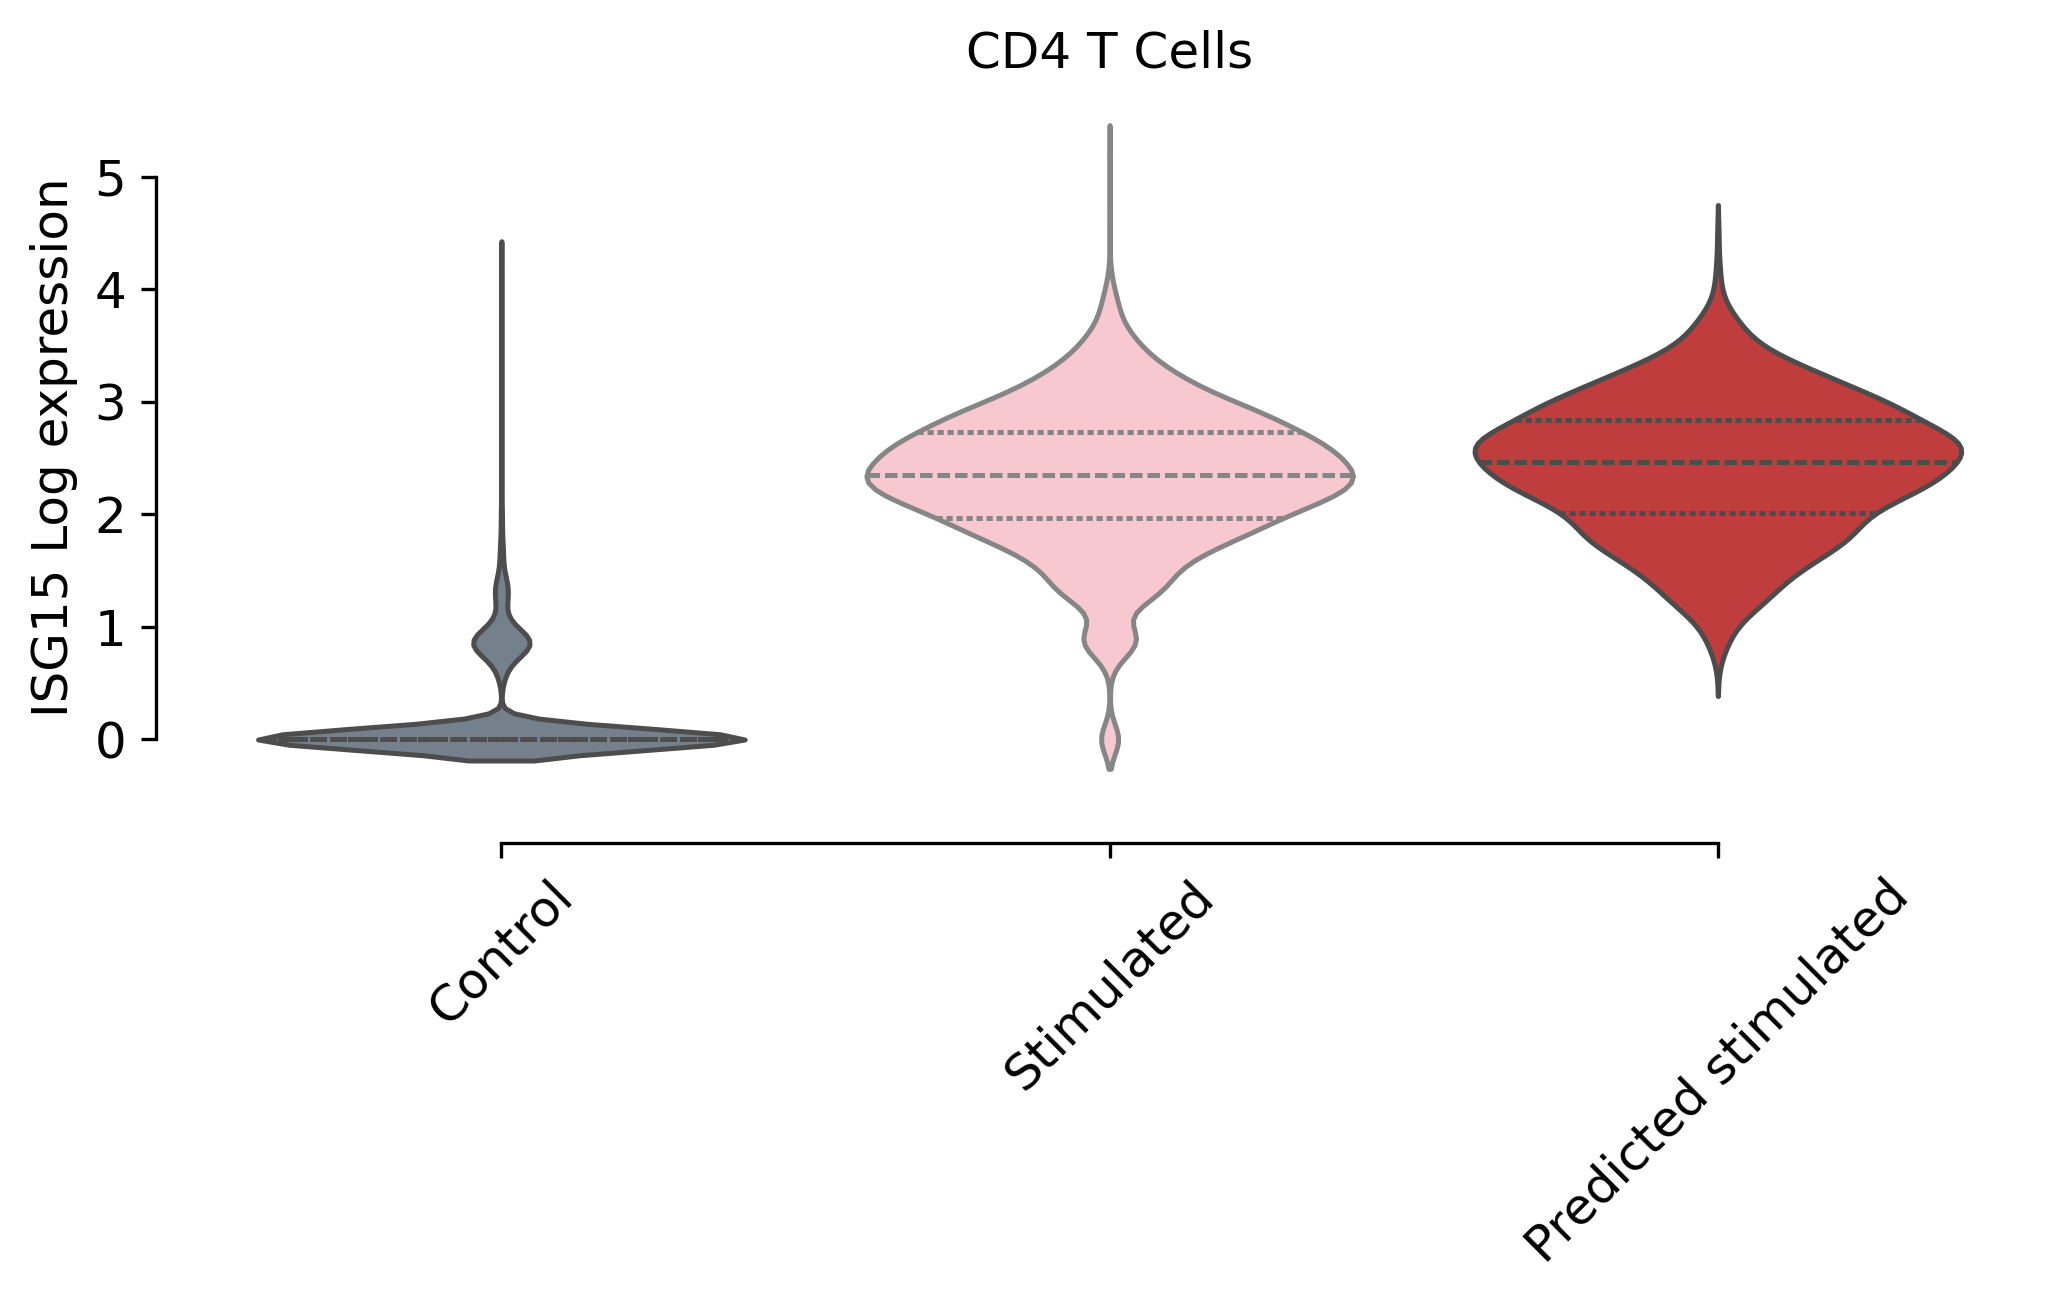

ttest pred-gt CD4 T TtestResult(statistic=4.907007289784746, pvalue=9.610268530425807e-07, df=4061.0)
ttest pred-control CD4 T TtestResult(statistic=137.2920514293992, pvalue=0.0, df=1633)


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
adata.X seems to be already log-transformed.


train_median 1692.5


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


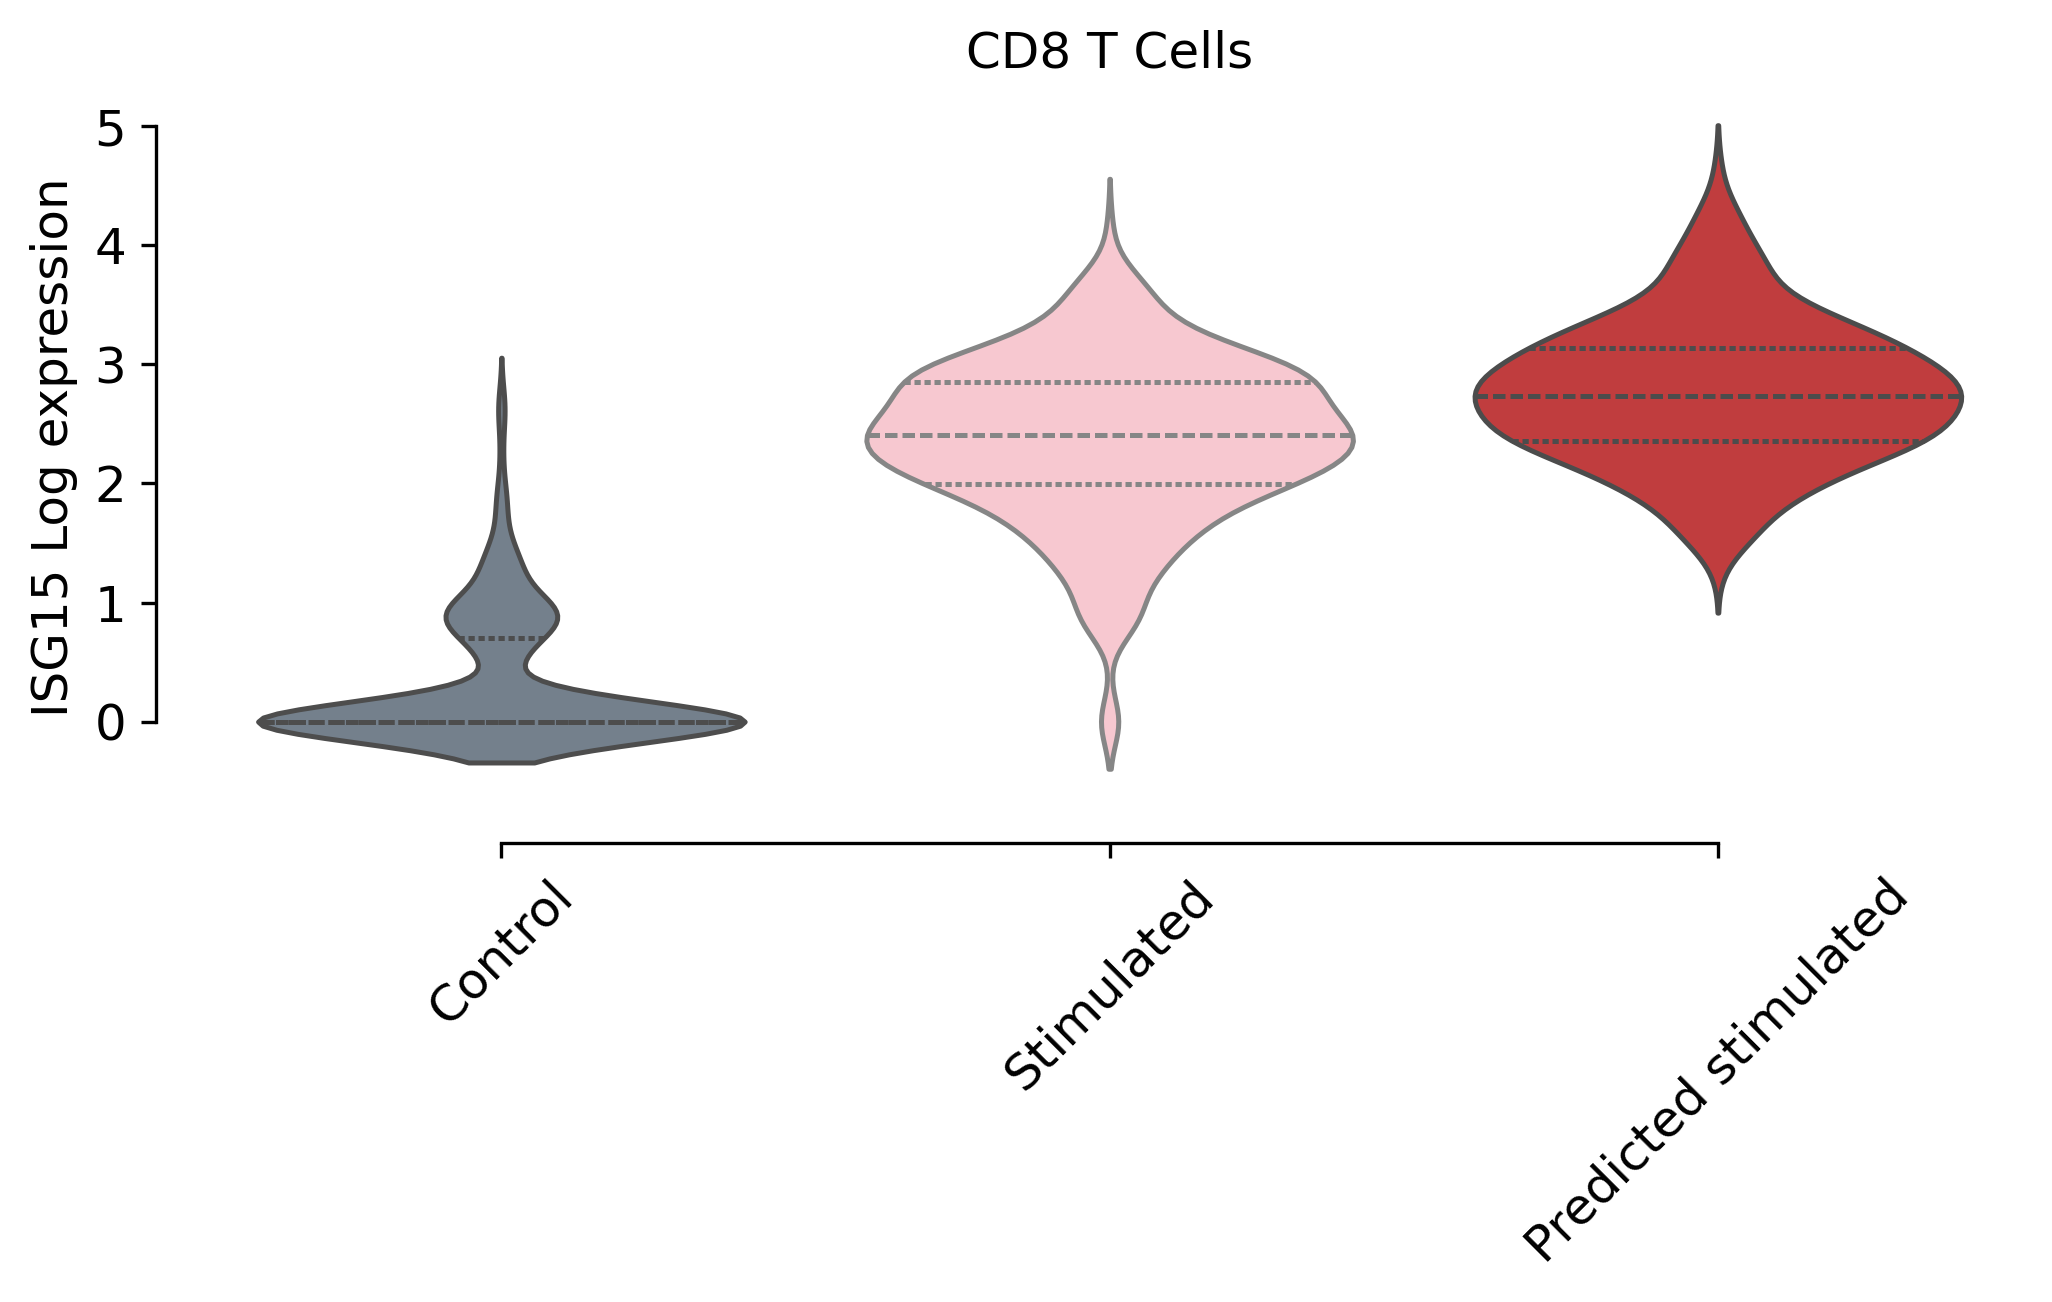

ttest pred-gt CD8 T TtestResult(statistic=8.36681906744097, pvalue=2.782757377426148e-16, df=768.0)
ttest pred-control CD8 T TtestResult(statistic=64.6692092905144, pvalue=6.958076777775312e-181, df=307)


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
adata.X seems to be already log-transformed.


train_median 1682.0


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


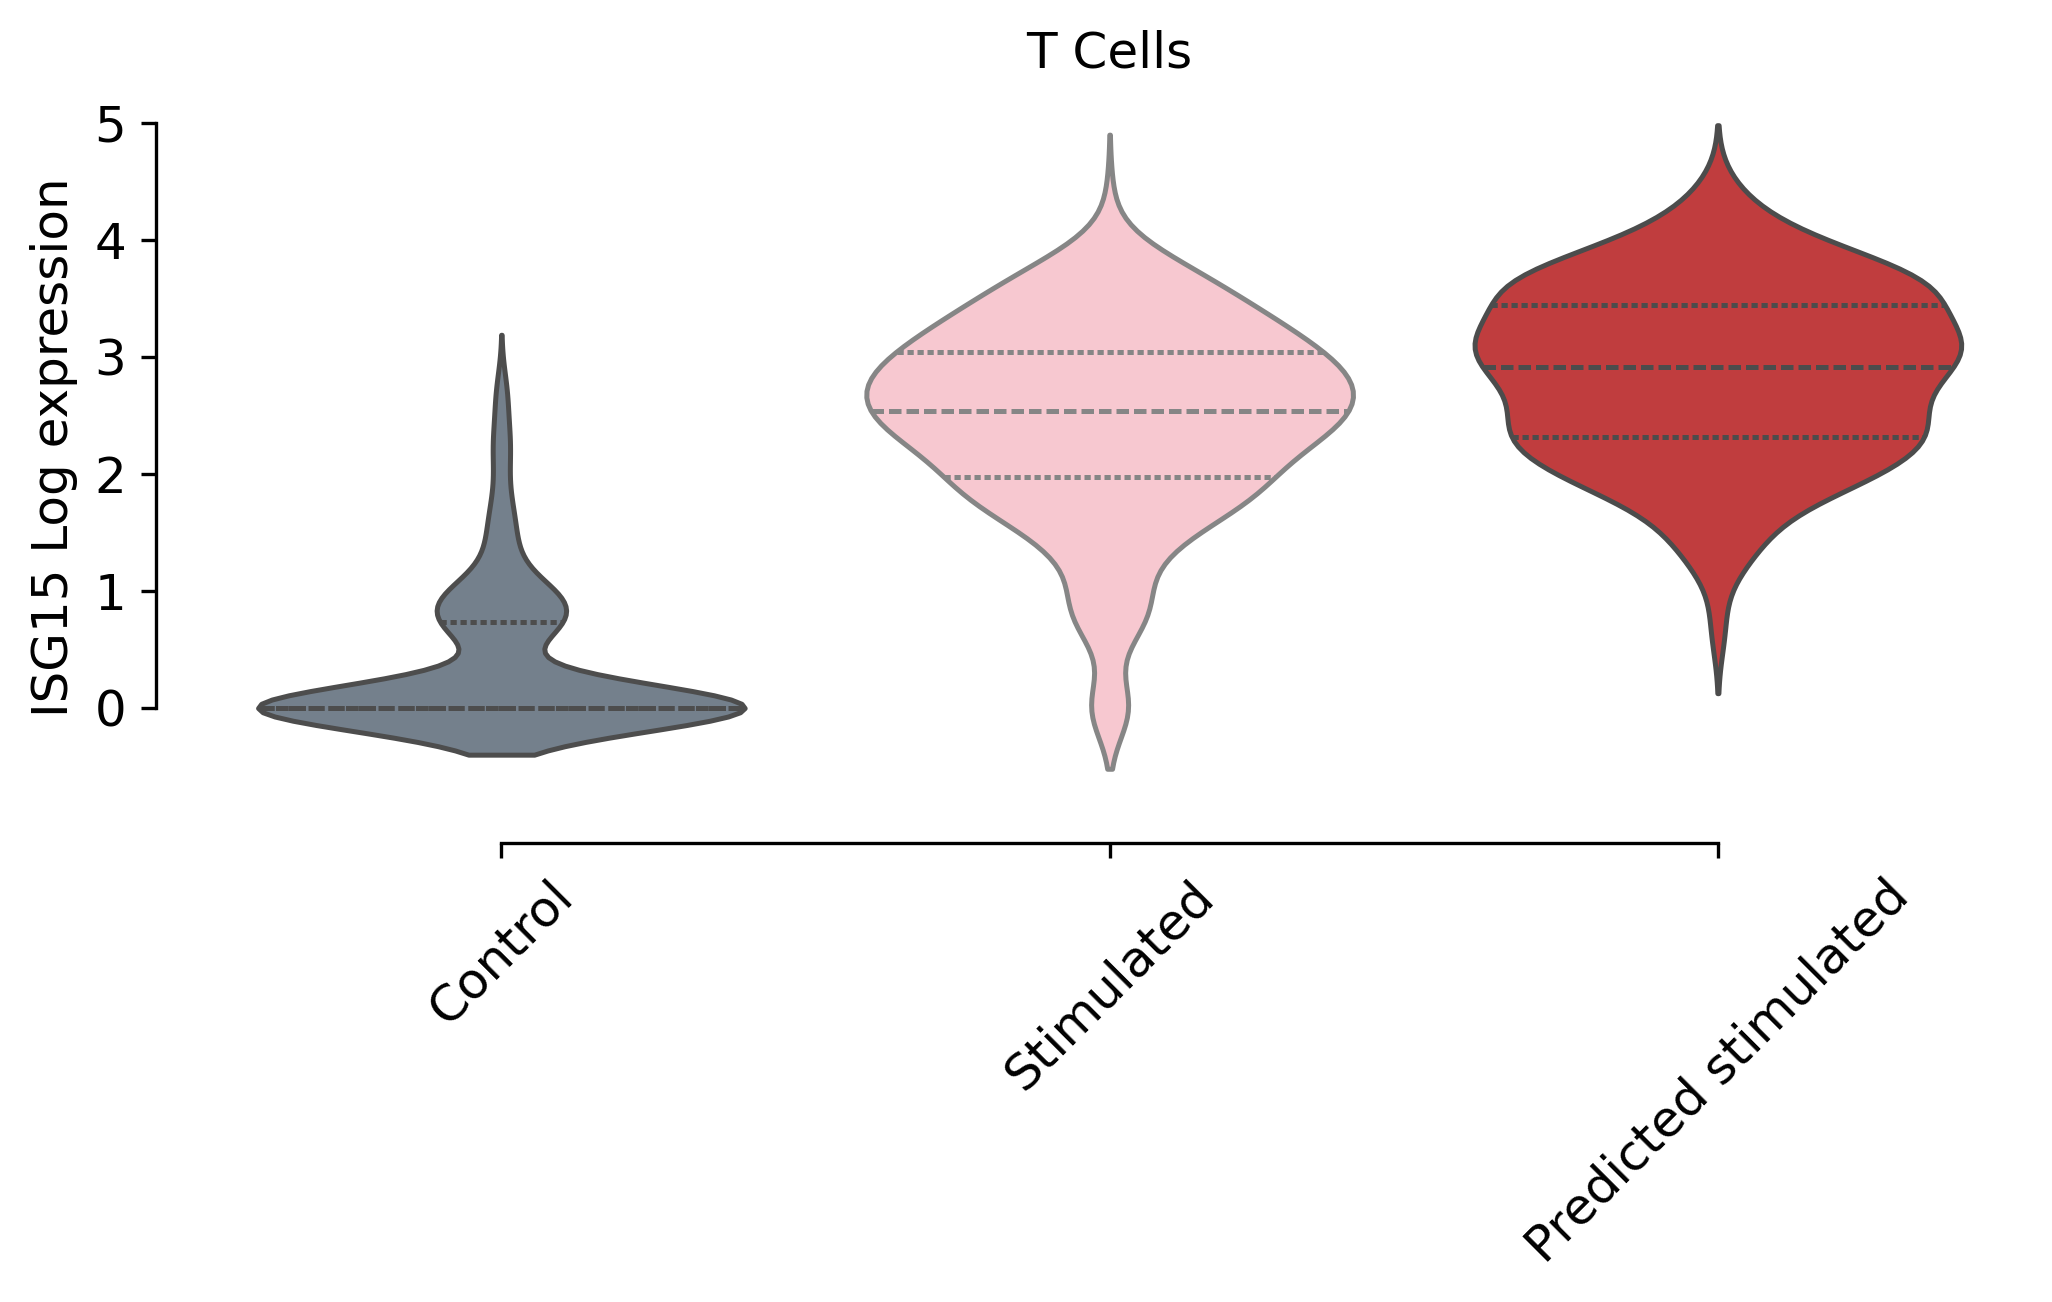

ttest pred-gt T TtestResult(statistic=6.0628548448094195, pvalue=2.3548535026168854e-09, df=605.0)
ttest pred-control T TtestResult(statistic=50.16025050496099, pvalue=8.650858139412338e-140, df=273)


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
adata.X seems to be already log-transformed.


train_median 1684.0


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


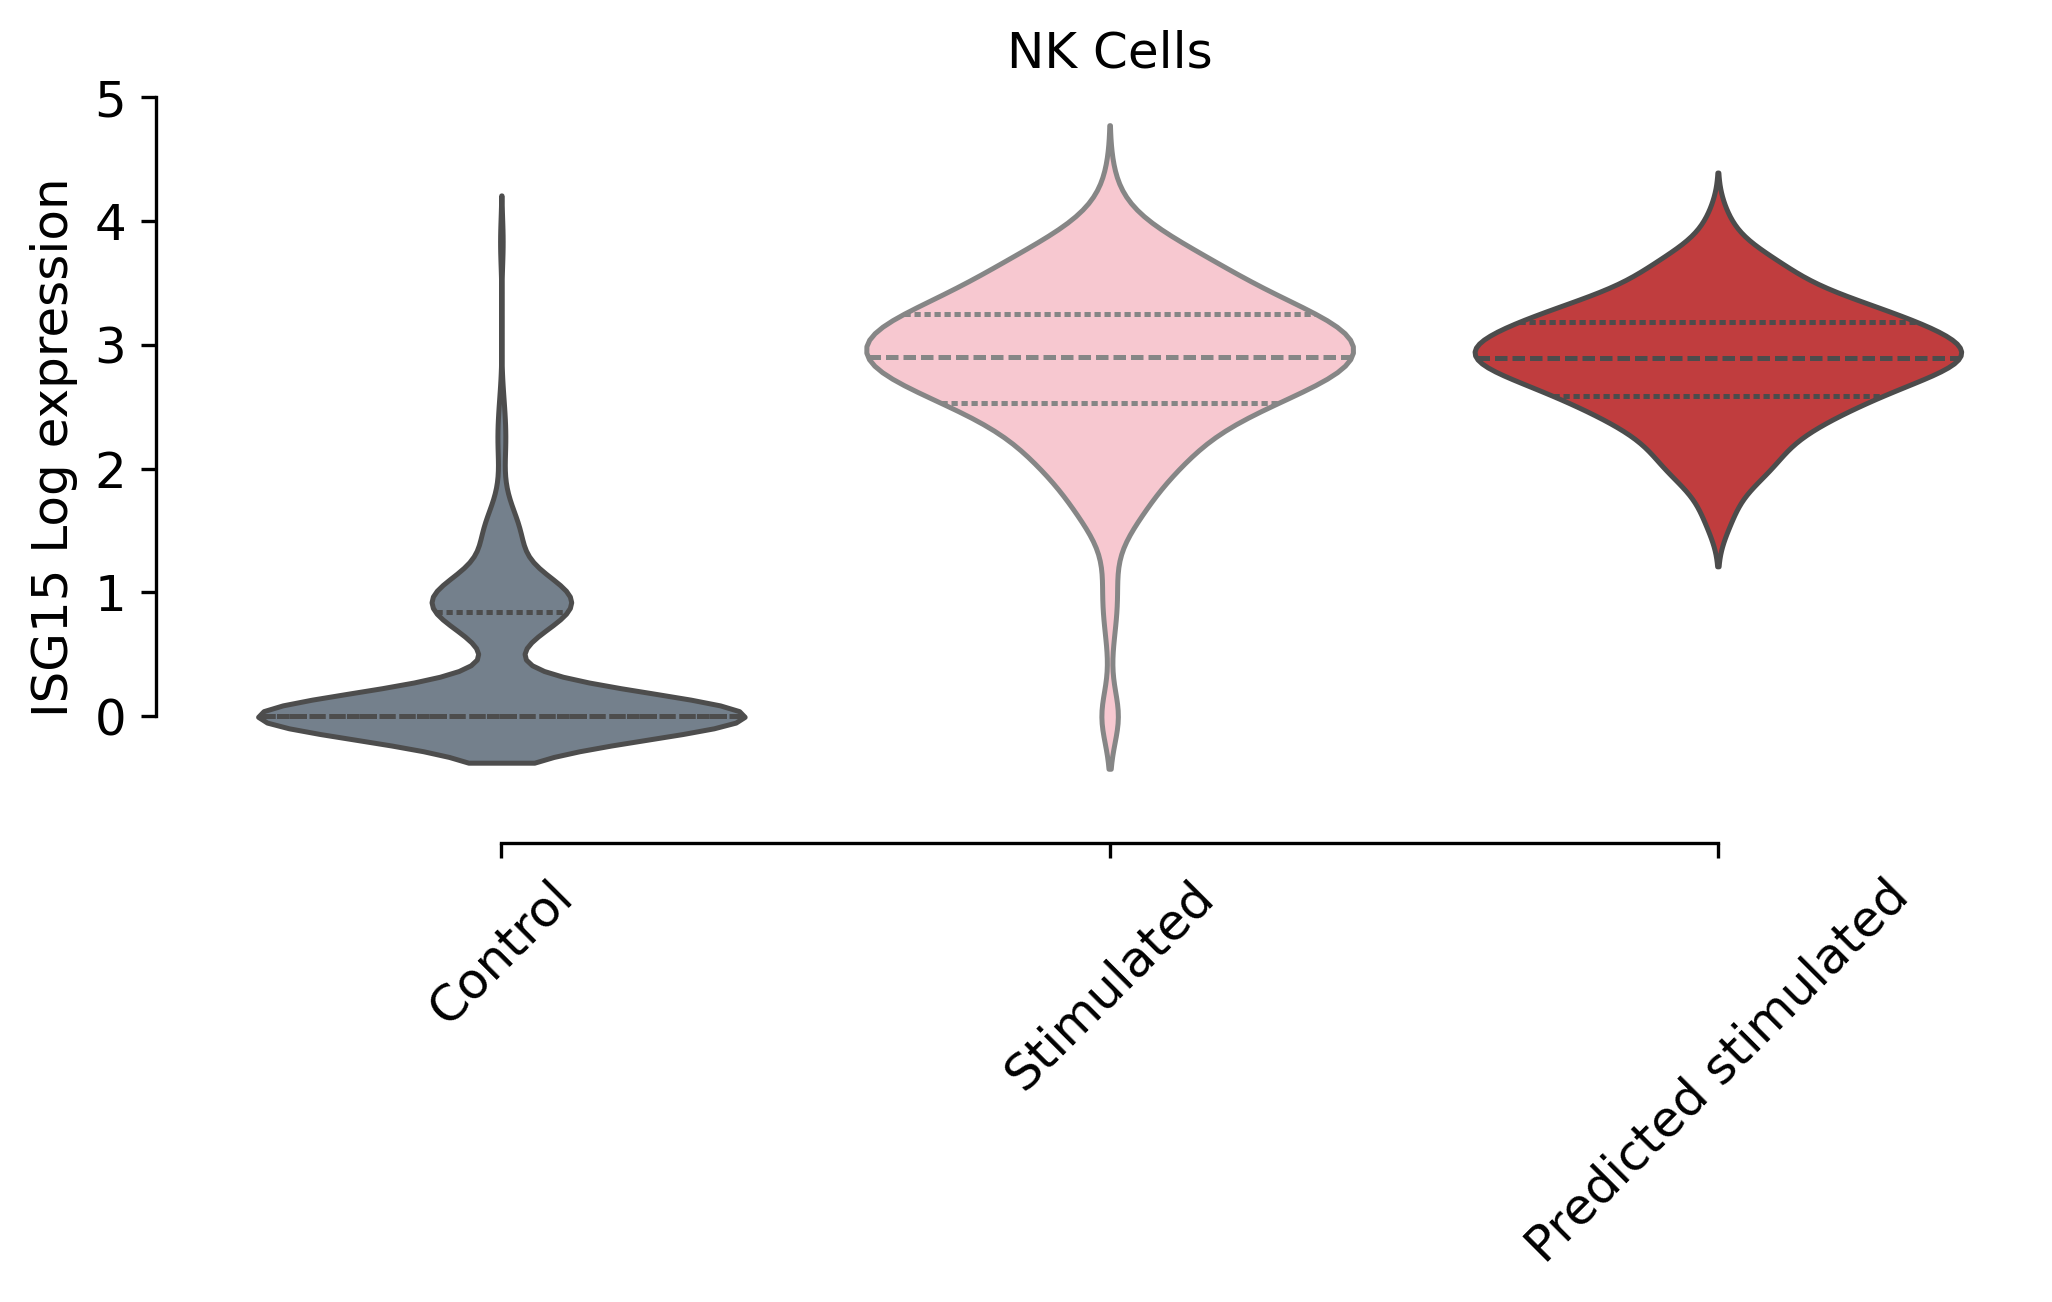

ttest pred-gt NK TtestResult(statistic=0.6803311450429367, pvalue=0.4965589955127351, df=596.0)
ttest pred-control NK TtestResult(statistic=63.81851981870305, pvalue=2.7902809970067016e-167, df=276)


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
adata.X seems to be already log-transformed.


train_median 1530.0


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


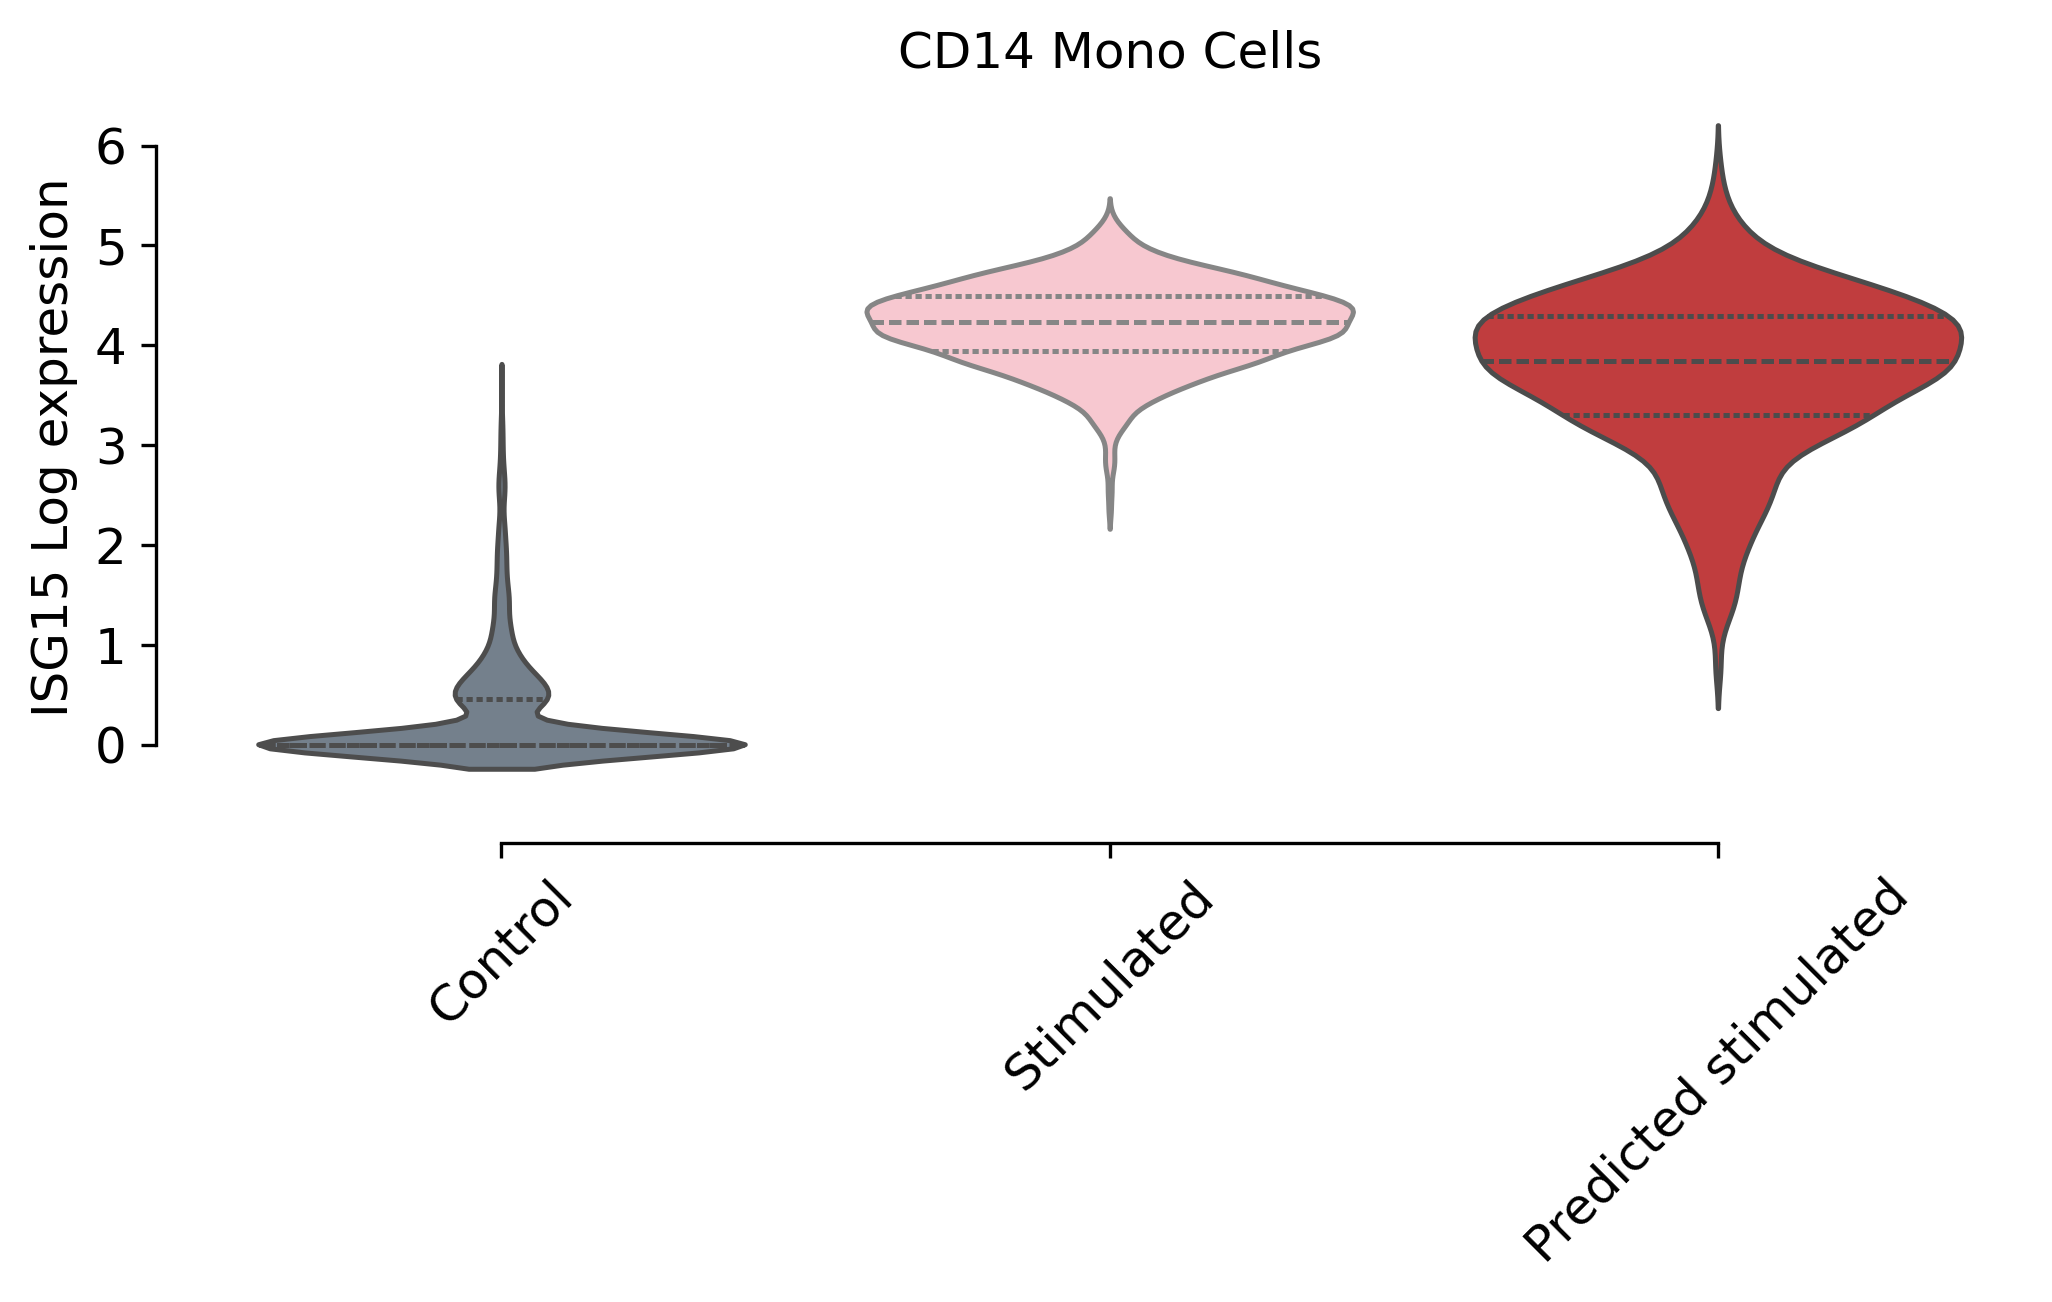

ttest pred-gt CD14 Mono TtestResult(statistic=-24.061842404067892, pvalue=6.933748136826549e-120, df=4159.0)
ttest pred-control CD14 Mono TtestResult(statistic=197.223248396419, pvalue=0.0, df=2013)


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
adata.X seems to be already log-transformed.


train_median 1631.0


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


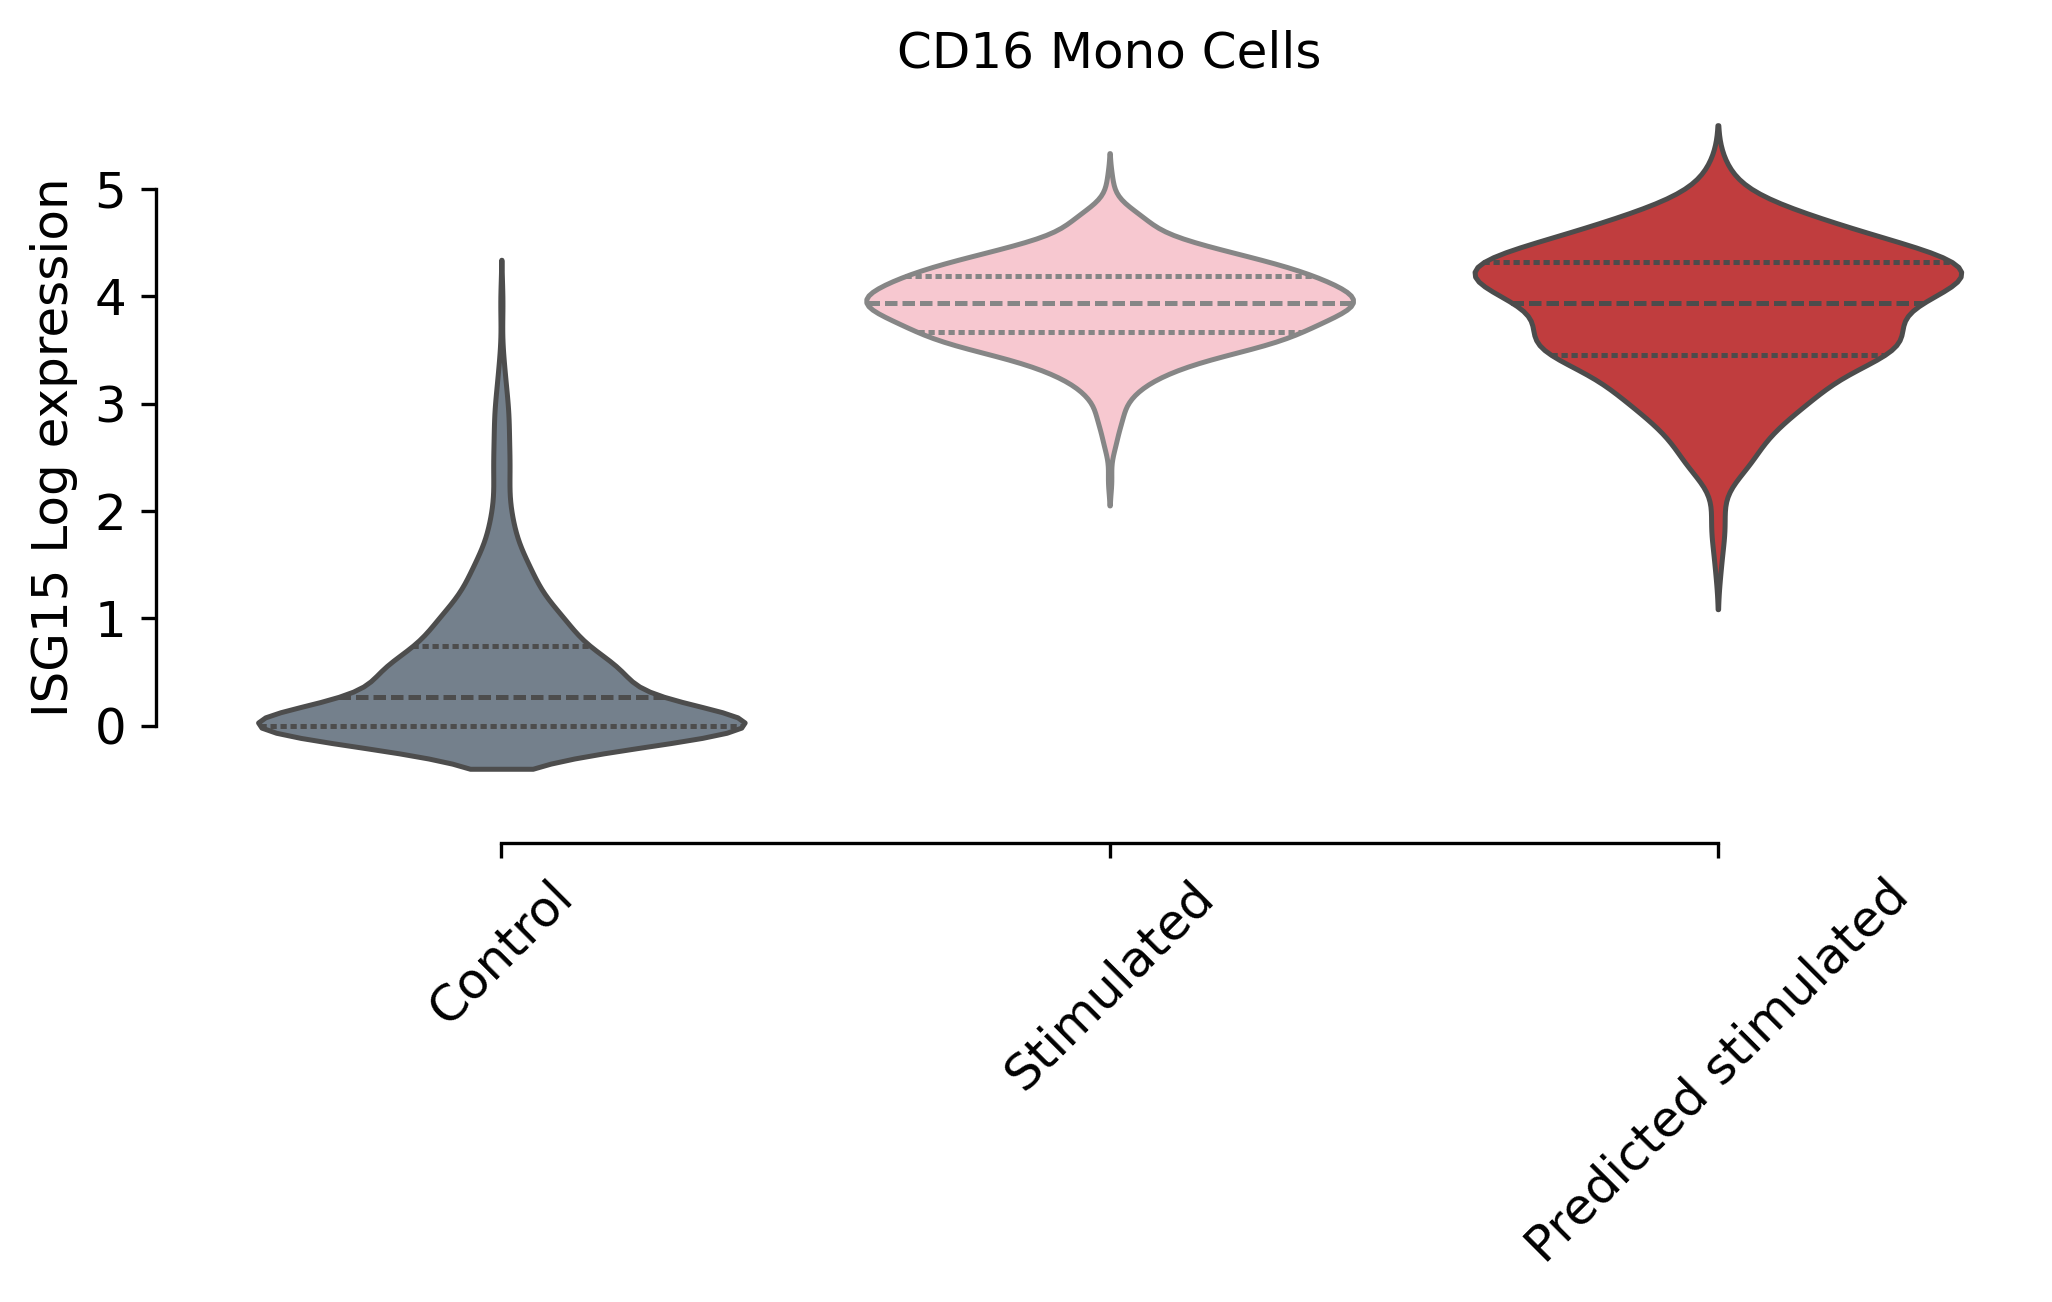

ttest pred-gt CD16 Mono TtestResult(statistic=-2.473541273735937, pvalue=0.013546015333059774, df=984.0)
ttest pred-control CD16 Mono TtestResult(statistic=101.31582815062676, pvalue=5.9212774022566e-311, df=448)


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
adata.X seems to be already log-transformed.


train_median 1652.0


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


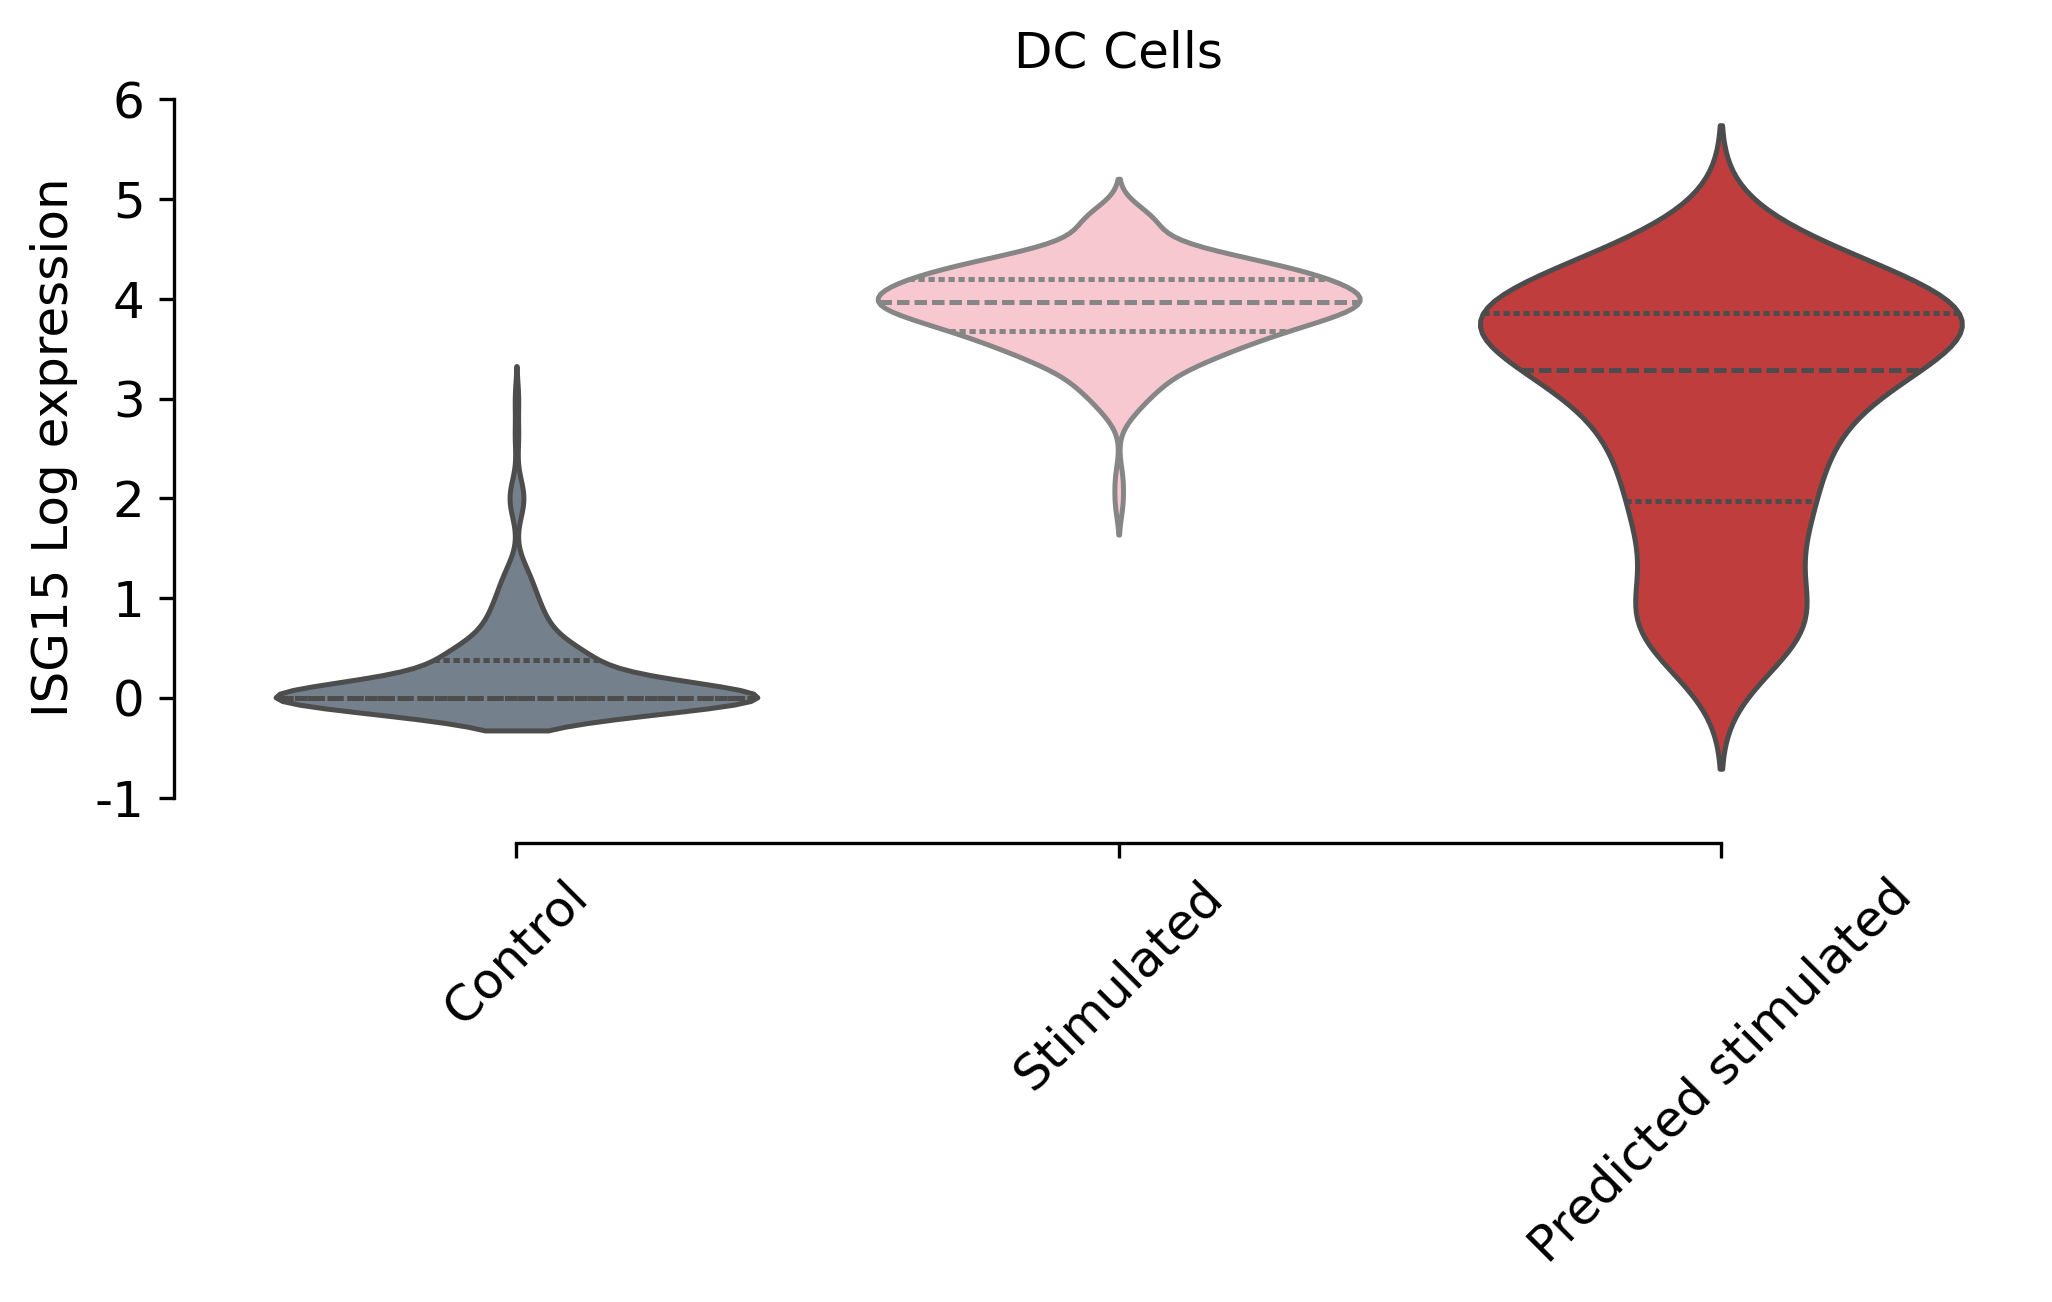

ttest pred-gt DC TtestResult(statistic=-11.456194014796578, pvalue=9.456005658726369e-27, df=437.0)
ttest pred-control DC TtestResult(statistic=35.03080852257538, pvalue=7.5532739493851134e-93, df=224)


In [6]:
for cell_type in ['B', 'CD4 T', 'CD8 T', 'T', 'NK', 'CD14 Mono', 'CD16 Mono', 'DC']:
    get_violin(ood_cov=cell_type, save_path=f'{save_dir}/{cell_type}')